<a href="https://colab.research.google.com/github/Shreyansh260/pytorch-notebooks/blob/main/Pytorch_Lightning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 70.4 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD

import lightning as L
from torch.utils.data import TensorDataset,DataLoader

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
class BasicLightning(L.LightningModule):
  def __init__(self):
    super().__init__()
    self.w00 = nn.Parameter(torch.tensor(1.7),requires_grad=False)
    self.b00 = nn.Parameter(torch.tensor(-0.85),requires_grad=False)
    self.w01 = nn.Parameter(torch.tensor(-40.8),requires_grad=False)
    self.w10 = nn.Parameter(torch.tensor(12.6),requires_grad=False)
    self.b10 = nn.Parameter(torch.tensor(0.0),requires_grad=False)
    self.w11 = nn.Parameter(torch.tensor(2.7),requires_grad=False)

    self.final_bias = nn.Parameter(torch.tensor(-16.),requires_grad=False)
  def forward(self,input):
    input_to_top_relu = input*self.w00 + self.b00
    top_relu_output = F.relu(input_to_top_relu)
    scaled_top_relu_output = top_relu_output*self.w01

    input_to_bottom_relu = input*self.w10 + self.b10
    bottom_relu_output = F.relu(input_to_bottom_relu)
    scaled_bottom_relu_output = bottom_relu_output*self.w11
    input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

    output = F.relu(input_to_final_relu)
    return output



In [4]:
input_doses = torch.linspace(start=0,end=1,steps=11)
model = BasicLightning()
output_values = model(input_doses)

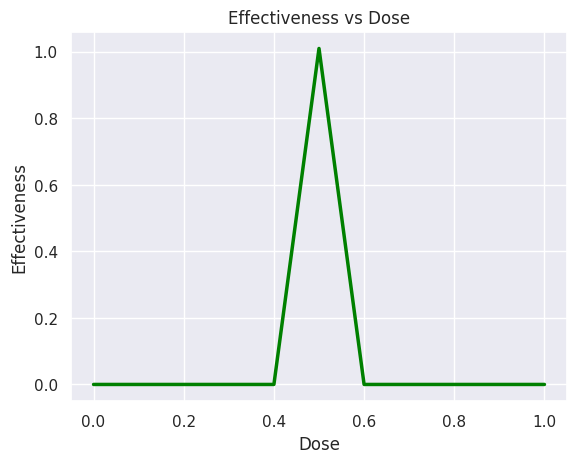

In [5]:
sns.set(style = 'darkgrid')
sns.lineplot(
    x= input_doses,
    y=output_values,
    color='green',
    linewidth = 2.5
)
plt.xlabel('Dose')
plt.ylabel('Effectiveness')
plt.title('Effectiveness vs Dose')
plt.show()

In [6]:
class BasicLightningTrain(L.LightningModule):
  def __init__(self):
    super().__init__()
    self.w00 = nn.Parameter(torch.tensor(1.7),requires_grad=False)
    self.b00 = nn.Parameter(torch.tensor(-0.85),requires_grad=False)
    self.w01 = nn.Parameter(torch.tensor(-40.8),requires_grad=False)
    self.w10 = nn.Parameter(torch.tensor(12.6),requires_grad=False)
    self.b10 = nn.Parameter(torch.tensor(0.0),requires_grad=False)
    self.w11 = nn.Parameter(torch.tensor(2.7),requires_grad=False)

    self.final_bias = nn.Parameter(torch.tensor(0.0),requires_grad=True)
    self.learning_rate = 0.01
  def forward(self,input):
    input_to_top_relu = input*self.w00 + self.b00
    top_relu_output = F.relu(input_to_top_relu)
    scaled_top_relu_output = top_relu_output*self.w01

    input_to_bottom_relu = input*self.w10 + self.b10
    bottom_relu_output = F.relu(input_to_bottom_relu)
    scaled_bottom_relu_output = bottom_relu_output*self.w11
    input_to_final_relu = scaled_top_relu_output + scaled_bottom_relu_output + self.final_bias

    output = F.relu(input_to_final_relu)
    return output


  def configure_optimizers(self):
    return SGD(self.parameters(),lr = self.learning_rate)


  def training_step(self,batch,batch_idx):
    input_i,labels_i = batch
    output_i = self.forward(input_i)
    loss = (output_i - labels_i)**2

    return loss




In [7]:
input = torch.tensor([0.,0.5,1.])
labels = torch.tensor([0.,1.,0.])

dataset = TensorDataset(input,labels)
dataloader = DataLoader(dataset)

In [8]:
from lightning.pytorch.callbacks import early_stopping
from lightning.pytorch.tuner import Tuner

model = BasicLightningTrain()
trainer = L.Trainer(max_epochs=34,accelerator='auto',devices='auto')

# Create tuner
tuner = Tuner(trainer)

# Use tuner
lr_find_results = tuner.lr_find(
    model,
    train_dataloaders=dataloader,
    min_lr=0.001,
    max_lr=1.0,
    early_stop_threshold=None,
)

new_lr = lr_find_results.suggestion()
print(f"New Learning rate: {new_lr}")

model.learning_rate = new_lr

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: True, using: 1 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: True, using: 1 TPU cores
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments plat

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_steps=100` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO: Restoring states from the checkpoint path at /content/.lr_find_9b5192f0-0da7-4132-b8ef-a22bff13a35a.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_9b5192f0-0da7-4132-b8ef-a22bff13a35a.ckpt
INFO: Restored all states from the checkpoint at /content/.lr_find_9b5192f0-0da7-4132-b8ef-a22bff13a35a.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restored all states from the checkpoint at /content/.lr_find_9b5192f0-0da7-4132-b8ef-a22bff13a35a.ckpt
INFO: Learning rate set to 0.002137962089502232
INFO:lightning.pytorch.tuner.lr_finder:Learning rate set to 0.002137962089502232


New Learning rate: 0.002137962089502232


In [9]:
trainer.fit(model,train_dataloaders=dataloader)
print(model.final_bias.data)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│   │ other params │ n/a  │      7 │ n/a  │   n/a │
└───┴──────────────┴──────┴────────┴──────┴───────┘

Trainable params: 1                                                                                                
Non-trainable params: 6                                                                                            
Total params: 7                                                                                                    
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 0                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=34` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=34` reached.


tensor(-2.1706)


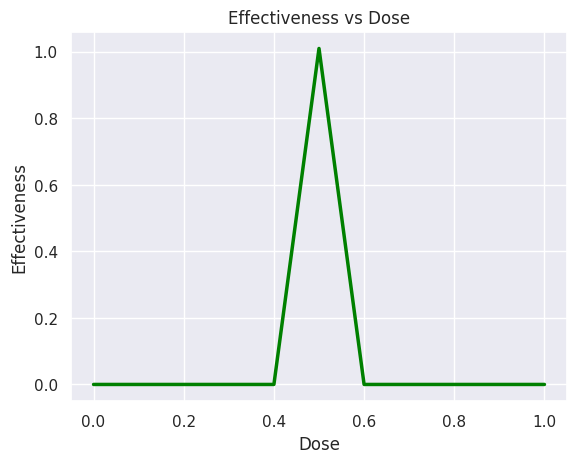

In [10]:

sns.set(style = 'darkgrid')
sns.lineplot(
    x= input_doses,
    y=output_values,
    color='green',
    linewidth = 2.5
)
plt.xlabel('Dose')
plt.ylabel('Effectiveness')
plt.title('Effectiveness vs Dose')
plt.show()